# 02 — LSTM Model

Build, train, and evaluate the LSTM model for next-day stock price prediction.

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
sns_style = 'darkgrid'

print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Load & Prepare Data

In [2]:
import yfinance as yf
from src.data_loader import clean_data, split_data, scale_data, build_sequences
from src.features import build_features, get_feature_columns

TICKER  = 'AAPL'
START   = '2018-01-01'
END     = '2024-01-01'
SEQ_LEN = 60  # look-back window

df_raw = yf.download(TICKER, start=START, end=END, auto_adjust=True)
df_raw.columns = df_raw.columns.get_level_values(0)
df_raw = df_raw[['Open','High','Low','Close','Volume']]

df        = build_features(clean_data(df_raw))
feat_cols = get_feature_columns(df)

train_df, val_df, test_df = split_data(df)
scaled = scale_data(train_df, val_df, test_df,
                    feature_cols=feat_cols, target_col='Close')

X_train, y_train = build_sequences(scaled['train'], feat_cols, seq_len=SEQ_LEN)
X_val,   y_val   = build_sequences(scaled['val'],   feat_cols, seq_len=SEQ_LEN)
X_test,  y_test  = build_sequences(scaled['test'],  feat_cols, seq_len=SEQ_LEN)

print(f'X_train: {X_train.shape}  X_val: {X_val.shape}  X_test: {X_test.shape}')

[*********************100%***********************]  1 of 1 completed


[features] Dropped 50 NaN rows after feature engineering.
[features] Final shape: (1459, 33)  |  Columns: 33
[data_loader] Split → train: 1021 | val: 219 | test: 219
[data_loader] Scalers saved → data/processed
X_train: (961, 60, 32)  X_val: (159, 60, 32)  X_test: (159, 60, 32)


## 2. Build LSTM Model

In [3]:
from src.lstm_model import build_lstm

model = build_lstm(
    input_shape=(SEQ_LEN, len(feat_cols)),
    lstm_units=[128, 64],
    dropout_rate=0.2,
    learning_rate=1e-3,
)
model.summary()

Model: "StockLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 60, 128)        │        82,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 60, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,721 (526.25 KB)

 Trainable params: 134,337 (524.75 KB)

 Non-trainable params: 384 (1.50 KB)

## 3. Train

In [4]:
from src.lstm_model import train_lstm, plot_training_history

result = train_lstm(
    model, X_train, y_train, X_val, y_val,
    epochs=100,
    batch_size=32,
    save_dir='../results',
)

plot_training_history(result['history'], save_dir='../results/plots')

[lstm] Training on 961 samples | Validating on 159 samples
[lstm] Input shape: (60, 32)
Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 15s 158ms/step - loss: 0.6524 - mae: 0.6211 - val_loss: 0.1236 - val_mae: 0.3439 - learning_rate: 0.0010
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 128ms/step - loss: 0.3048 - mae: 0.4405 - val_loss: 0.0252 - val_mae: 0.1426 - learning_rate: 0.0010
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - loss: 0.1976 - mae: 0.3537 - val_loss: 0.0764 - val_mae: 0.2681 - learning_rate: 0.0010
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step - loss: 0.1826 - mae: 0.3407 - val_loss: 0.0437 - val_mae: 0.1987 - learning_rate: 0.0010
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 115ms/step - loss: 0.1503 - mae: 0.3087 - val_loss: 0.0241 - val_mae: 0.1419 - learning_rate: 0.0010
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 112ms/step - loss: 0.1011 - mae: 0.2546 - val_loss: 0.0547 - val_mae: 0.2250 - learning_rate: 0.0010
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step 

## 4. Training Curves

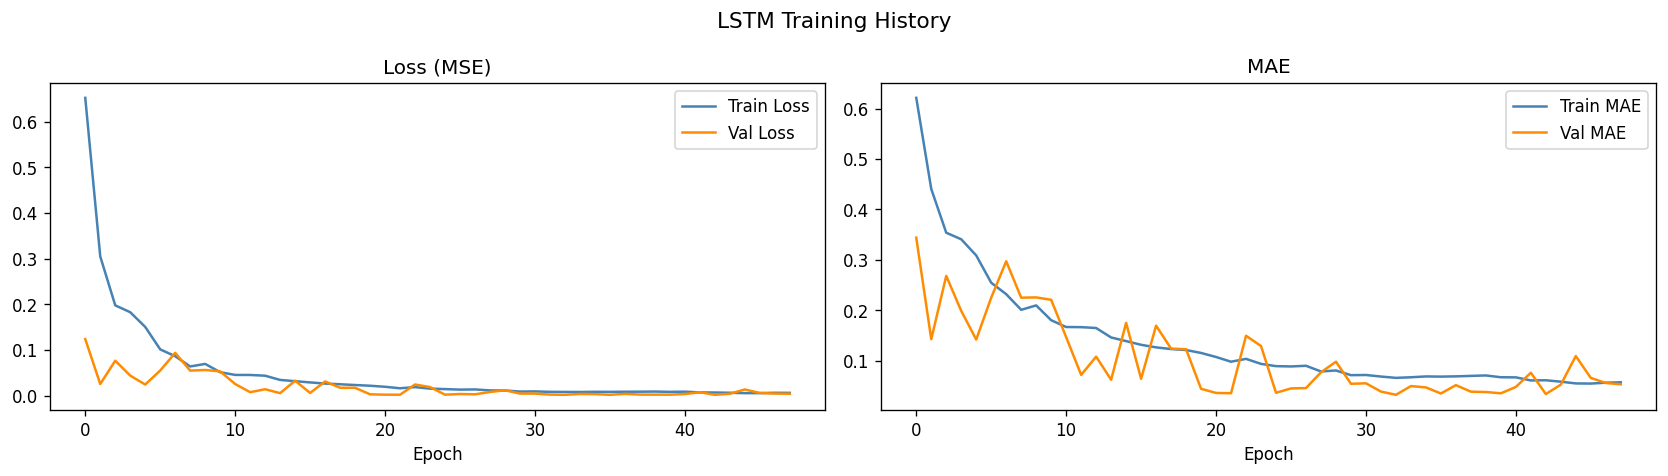

Best epoch: 33  |  Val Loss: 0.001570


In [5]:
history = result['history'].history

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history['loss'],     label='Train Loss', color='steelblue')
axes[0].plot(history['val_loss'], label='Val Loss',   color='darkorange')
axes[0].set_title('Loss (MSE)')
axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history['mae'],     label='Train MAE', color='steelblue')
axes[1].plot(history['val_mae'], label='Val MAE',   color='darkorange')
axes[1].set_title('MAE')
axes[1].set_xlabel('Epoch'); axes[1].legend()

plt.suptitle('LSTM Training History', fontsize=13)
plt.tight_layout(); plt.show()

best_epoch = np.argmin(history['val_loss']) + 1
print(f'Best epoch: {best_epoch}  |  Val Loss: {min(history["val_loss"]):.6f}')

## 5. Evaluate on Test Set

In [6]:
from src.lstm_model import evaluate_lstm

lstm_result = evaluate_lstm(
    result['model'],
    X_test, y_test,
    target_scaler=scaled['target_scaler'],
    save_dir='../results',
)

y_true      = lstm_result['y_true']
y_pred_lstm = lstm_result['y_pred']
metrics     = lstm_result['metrics']

print('\nTest Metrics:')
for k, v in metrics.items():
    print(f'  {k:<25}: {v:.4f}')

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 300ms/step

── LSTM Metrics ────────────────────────
  MAE                      : 8.8144
  RMSE                     : 10.3880
  MAPE                     : 4.7535
  Directional_Accuracy     : 47.4684

[lstm] Prediction plot saved → ../results\plots\lstm_predictions.png

Test Metrics:
  MAE                      : 8.8144
  RMSE                     : 10.3880
  MAPE                     : 4.7535
  Directional_Accuracy     : 47.4684


## 6. Prediction Plot

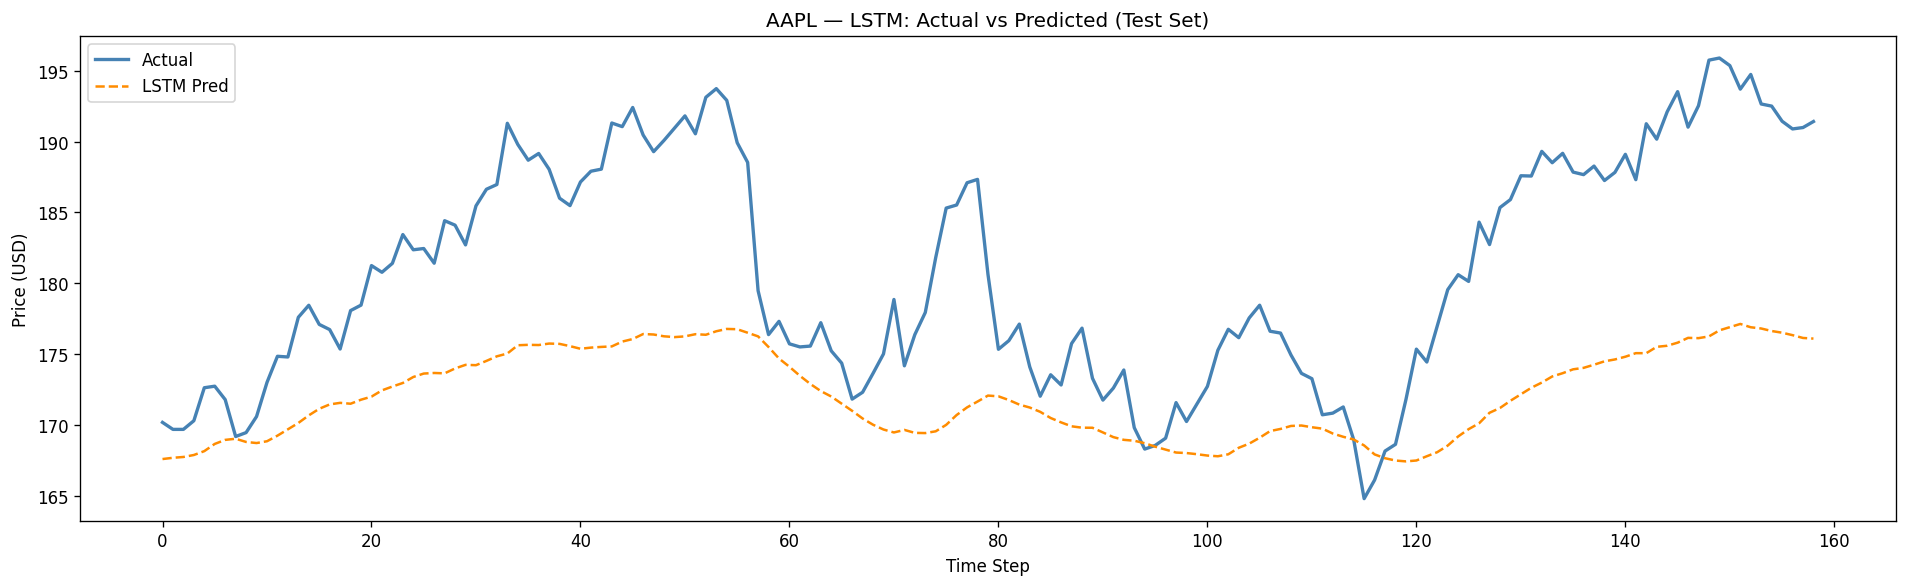

In [7]:
plt.figure(figsize=(16, 5))
plt.plot(y_true,      label='Actual',    color='steelblue',  linewidth=2.0)
plt.plot(y_pred_lstm, label='LSTM Pred', color='darkorange', linewidth=1.5, linestyle='--')
plt.title(f'{TICKER} — LSTM: Actual vs Predicted (Test Set)')
plt.xlabel('Time Step'); plt.ylabel('Price (USD)')
plt.legend(); plt.tight_layout(); plt.show()

## 7. Residual Analysis

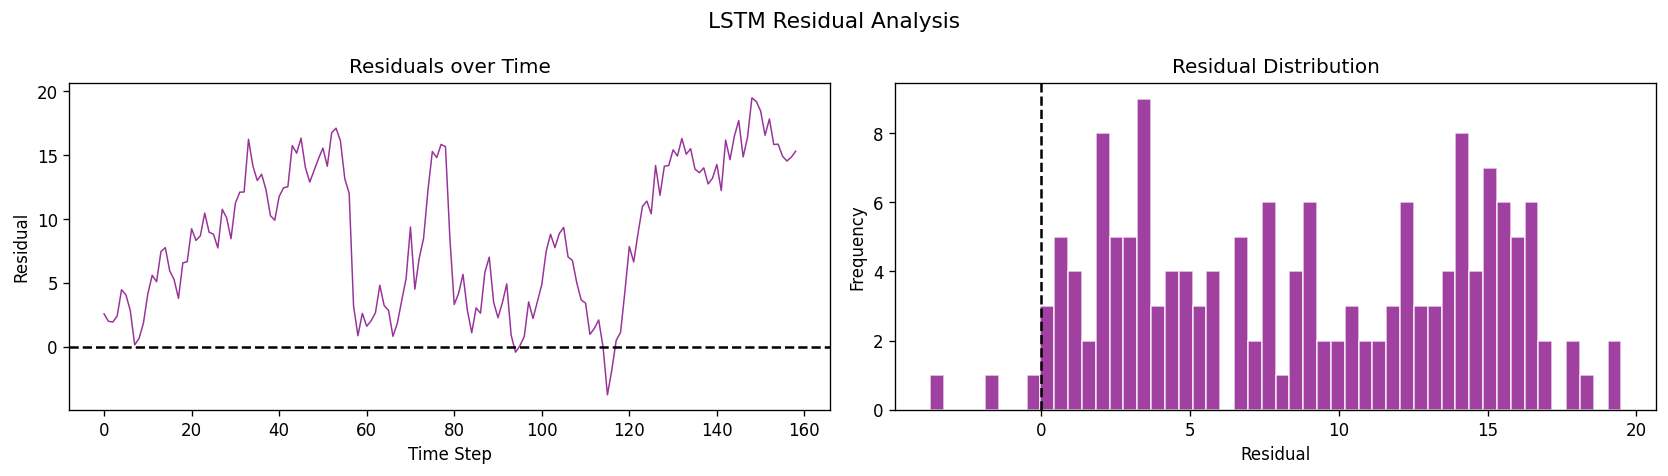

Mean residual : 8.7391
Std residual  : 5.6160


In [8]:
residuals = y_true - y_pred_lstm

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(residuals, color='purple', linewidth=0.9, alpha=0.8)
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_title('Residuals over Time')
axes[0].set_xlabel('Time Step'); axes[0].set_ylabel('Residual')

axes[1].hist(residuals, bins=50, color='purple', alpha=0.75, edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual'); axes[1].set_ylabel('Frequency')

plt.suptitle('LSTM Residual Analysis', fontsize=13)
plt.tight_layout(); plt.show()

print(f'Mean residual : {residuals.mean():.4f}')
print(f'Std residual  : {residuals.std():.4f}')

## 8. Save Model

In [9]:
from src.lstm_model import save_lstm
save_lstm(result['model'], path='../results/lstm_final.keras')
print('LSTM notebook complete ✓')

[lstm] Model saved → ../results/lstm_final.keras
LSTM notebook complete ✓
